In [ ]:
import os

# 1. Definir la ruta exacta
zip_path = '/content/drive/MyDrive/Carrera/Inteligencia Artificial/dataset_final.zip' 
extract_path = '/content/dataset'

# 2. Descomprimir usando comillas para evitar errores de espacios
if os.path.exists(zip_path):
    # Usamos f-strings con comillas dobles para que Linux entienda la ruta completa
    !unzip -q "{zip_path}" -d {extract_path}
    print("✅ ¡Dataset descomprimido con éxito en /content/dataset!")
else:
    print(f"❌ Error: No se encontró el archivo en: {zip_path}")
    # Esto ayuda a ver qué carpetas sí existen para corregir la ruta
    print("Contenido de la carpeta Carrera:")
    !ls "/content/drive/MyDrive/Carrera/"

✅ ¡Dataset descomprimido con éxito en /content/dataset!


In [5]:
!ls /content/dataset/dataset_final/train/objeto_a | head -n 5

001_c1.jpg
001_c2.jpg
001_c3.jpg
001_c4.jpg
002_c1.jpg


Found 1120 files belonging to 2 classes.
Found 148 files belonging to 2 classes.
Found 156 files belonging to 2 classes.

🚀 Iniciando entrenamiento...
Epoch 1/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 63s 2s/step - accuracy: 0.4571 - loss: 0.7954 - val_accuracy: 0.4122 - val_loss: 0.7422
Epoch 2/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.5375 - loss: 0.7094 - val_accuracy: 0.5811 - val_loss: 0.6817
Epoch 3/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.6205 - loss: 0.6565 - val_accuracy: 0.6351 - val_loss: 0.6454
Epoch 4/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 52s 1s/step - accuracy: 0.6545 - loss: 0.6202 - val_accuracy: 0.7230 - val_loss: 0.5961
Epoch 5/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.7152 - loss: 0.5647 - val_accuracy: 0.7905 - val_loss: 0.5410
Epoch 6/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 52s 1s/step - accuracy: 0.7500 - loss: 0.5235 - val_accuracy: 0.8108 - val_loss: 0.5108
Epoch 7/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.7688 - loss: 0.4876 - val_acc

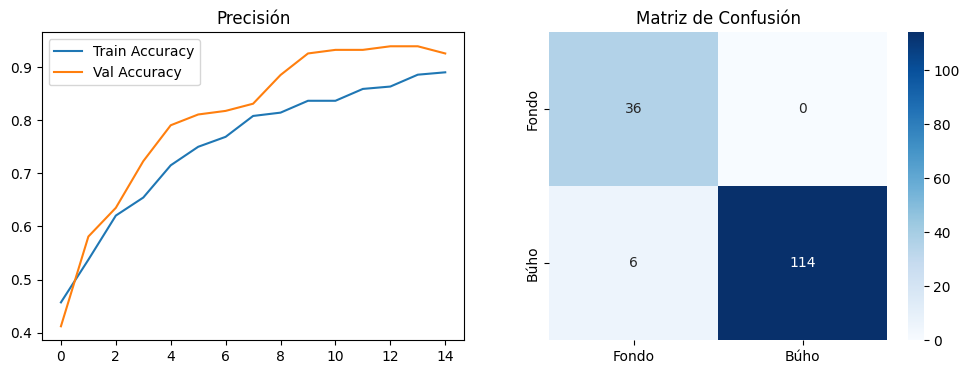

✅ Modelo guardado en: /content/drive/MyDrive/Carrera/Inteligencia Artificial/modelo_buho_v1.h5


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import os

# 1. Configuración de rutas (basado en el !ls exitoso)
base_path = '/content/dataset/dataset_final'
train_dir = os.path.join(base_path, 'train')
val_dir = os.path.join(base_path, 'val')
test_dir = os.path.join(base_path, 'test')

# 2. Carga de datos optimizada
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(train_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='binary')
val_ds = tf.keras.utils.image_dataset_from_directory(val_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='binary')
test_ds = tf.keras.utils.image_dataset_from_directory(test_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='binary', shuffle=False)

# 3. Arquitectura MobileNetV2 (Transfer Learning)
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False  # Congelamos el conocimiento previo

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2), # Para evitar que memorice (overfitting)
    layers.Dense(1, activation='sigmoid') # Salida binaria: 0 o 1
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# 4. Entrenamiento
print("\n🚀 Iniciando entrenamiento...")
history = model.fit(train_ds, validation_data=val_ds, epochs=15)

# 5. Visualización de Resultados
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Precisión')
plt.legend()

# 6. Matriz de Confusión
print("\n📊 Generando Matriz de Confusión...")
y_true = np.concatenate([y for x, y in test_ds], axis=0)
preds = model.predict(test_ds)
y_pred = (preds > 0.5).astype(int)

cm = confusion_matrix(y_true, y_pred)
plt.subplot(1, 2, 2)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fondo', 'Búho'], yticklabels=['Fondo', 'Búho'])
plt.title('Matriz de Confusión')
plt.show()

# 7. Guardar el modelo en Drive
model_save_path = '/content/drive/MyDrive/Carrera/Inteligencia Artificial/modelo_buho_v1.h5'
model.save(model_save_path)
print(f"✅ Modelo guardado en: {model_save_path}")